In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "tensorflow"
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import numpy as np
import math
from scipy import stats
import random

import keras
import bayesflow as bf
from functools import partial

import numba as nb
import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

import pandas as pd

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
RNG = np.random.default_rng(SEED)

2026-05-06 15:20:12.798111: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 15:20:12.845866: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 15:20:18.979693: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
INFO:bayesflow:Using backend 'tensorflow'


In [2]:
import importlib, sys, subprocess

print("=== Python ===")
print(sys.version)

print("\n=== Package Versions ===")
for pkg_name in ["keras", "bayesflow", "numpy", "pandas", "matplotlib", "seaborn", "numba", "jax", "jaxlib"]:
    try:
        mod = importlib.import_module(pkg_name)
        print(f"{pkg_name}: {getattr(mod, '__version__', 'unknown')}")
    except ImportError:
        print(f"{pkg_name}: NOT INSTALLED")

=== Python ===
3.11.3 (main, Jun 12 2025, 13:20:10) [GCC 12.3.0]

=== Package Versions ===
keras: 3.11.3
bayesflow: 2.0.6
numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.10.6
seaborn: 0.13.2
numba: 0.62.1
jax: 0.4.28
jaxlib: 0.4.28


## Single trial simulation
The following cells implement the core simulation.
**You do not need to modify this code** to customize the model.

In [3]:
@nb.jit(nopython=True, cache=True)
def hcdm_trial(l, phi, a, zx, zy, ndt, dt=1e-3, max_steps=15000):
    """Simulates a trial from the diffusion model."""   
    n_steps = 0
    x = zx * a 
    y = zy * a

    x_target = a * math.cos(phi)
    y_target = a * math.sin(phi)

    V_x = x_target - x
    V_y = y_target - y

    magnitude = math.sqrt(V_x**2 + V_y**2)
    vx = l * (V_x / magnitude)
    vy = l * (V_y / magnitude)
    
    mu_x = vx * dt
    mu_y = vy * dt
    
    sigma = math.sqrt(dt)

    rt = float(max_steps) * dt + ndt
    resp = 0.0

    # Simulate a single DM path
    for n_steps in range(max_steps):
        # Generate random noise
        dx = mu_x + sigma * random.gauss(0.0, 1.0)
        dy = mu_y + sigma * random.gauss(0.0, 1.0)
        
        # Check if step would cross the boundary (y + dy <= 0)
        if y + dy <= 0:
            # Calculate exactly where we hit the boundary
            # We need to find t such that y + t * dy = 0
            # So t = -y / dy (assuming dy != 0)
            
            if abs(dy) > 1e-12:  # Avoid division by zero
                t_boundary = -y / dy  # Fraction of step to reach boundary
                
                # Move to the boundary
                x_boundary = x + t_boundary * dx
                y_boundary = 0.0  # Exactly at boundary
                
                # Calculate remaining step after hitting boundary
                dx_remaining = (1.0 - t_boundary) * dx
                dy_remaining = (1.0 - t_boundary) * dy
                
                # Reflect the remaining step (flip y-component)
                dx_reflected = dx_remaining
                dy_reflected = -dy_remaining
                
                # Apply the reflected remaining step
                x = x_boundary + dx_reflected
                y = y_boundary + dy_reflected
                
            else:
                # If dy is essentially zero, just move horizontally
                x += dx
                # y stays the same (no vertical movement)
                
        else:
            # Normal step - no boundary crossing
            x += dx
            y += dy
                
        # Check if we've reached the circular boundary
        if x**2 + y**2 >= a**2:
            rt = float(n_steps) * dt + ndt
            resp = math.atan2(y, x)
            break
            
         
    return rt, resp


In [4]:
hcdm_trial(l=1, phi=1, a=1, zx=0.2, zy=0.2, ndt=0.2)

(0.563, 1.294472550437839)

## ⚙️ Prior (customizable)

This function defines the prior distributions over all model parameters.
Modify the ranges below to match your experimental design.

### Parameter guide

| Parameter | Shape | Description | Default range |
|-----------|-------|-------------|---------------|
| `l` | `(n_conditions,)` | Drift rate length | [0.5, 9] |
| `phi` | `(n_conditions,)` | Drift rate direction | [0, pi] |
| `a` | scalar | Decision threshold | [0.5, 9] |
| `zx` | scalar | Starting point x-component | [-0.7, 0.7] |
| `zy` | scalar | Starting point y-component | [0, 0.7] |
| `ndt` | scalar | Non-decision time (seconds) | [0.1, 2.5] |

### Common modifications

**Change parameter ranges** (modify the numbers to match your experiment):

```python
l   = RNG.uniform(0.5, 9, size=(4,))
phi = RNG.uniform(0, np.pi, size=(4,))
a   = RNG.uniform(0.5, 9)
```

**Change number of conditions** (replace 4 with your n_conditions):

```python
l   = RNG.uniform(0.5, 9, size=(4,))
phi = RNG.uniform(0, np.pi, size=(4,))
```

**Make a shared parameter condition-specific** (example for `a`):

```python
a = RNG.uniform(0.5, 9)
a = RNG.uniform(0.5, 9, size=(4,))
```

In [4]:
def hcdm_prior():
    "Generates a random draw from the joint prior distribution."
    l = RNG.uniform(0.5, 9, size = (4,))
    phi = RNG.uniform(0, np.pi, size = (4,))
    a = RNG.uniform(0.5,9)
    zx = RNG.uniform(-0.7, 0.7)
    zy = RNG.uniform(0, 0.7)
    ndt = RNG.uniform(0.1, 2.5)
    return dict(l = l,
                phi = phi,
                a = a,
                zx = zx,
                zy = zy,
                ndt = ndt)

In [6]:
hcdm_prior()

{'l': array([1.24846287, 2.37374038, 1.46194971, 4.2652181 ]),
 'phi': array([2.19073127, 1.71588181, 2.39345536, 1.83752157]),
 'a': 8.12047534287261,
 'zx': -0.4888706370808591,
 'zy': 0.352898450577388,
 'ndt': 2.143328069706898}

## ⚙️ Experiment setup (customizable)

### Parameters you may need to modify

**Number of observations per condition** (default: 39–50):
```python
min_obs = 39  # minimum observations per condition
max_obs = 50  # maximum observations per condition
```

**Number of conditions** (default: 4):
```python
# in hcdm_experiment and hcdm_experiment_nb:
labels = np.repeat(np.arange(4), num_obs_per_condition)  # change 4 → your n_conditions
condition = np.eye(4)[labels]                             # change 4 → your n_conditions

# in meta:
num_obs_per_condition = np.random.randint(min_obs, max_obs, size=(4,))  # change 4 → your n_conditions
```

**Simulation precision** (in `hcdm_trial`):
```python
dt=1e-3,        # time step size, smaller = more precise but slower
max_steps=15000  # maximum integration steps per trial
```

**If you made `a`, `zx`, or `zy` condition-specific in the prior:**
```python
# current: shared
rt, resp = hcdm_trial(l[idx], phi[idx], a, zx, zy, ndt)

# condition-specific:
rt, resp = hcdm_trial(l[idx], phi[idx], a[idx], zx[idx], zy[idx], ndt)
```

### ⚠️ Do not modify
- `hcdm_experiment_nb` — Numba parallel kernel, changing parallel structure may cause errors
- The `labels` indexing logic — handles condition assignment correctly

In [7]:
#design matrix
min_obs = 39
max_obs = 50
def meta(batch_size, num_obs_per_condition=None):
    n = batch_size[0] if isinstance(batch_size, tuple) else batch_size
    if num_obs_per_condition is None:
        num_obs_per_condition = np.random.randint(min_obs, max_obs, size=(4,))  # one draw
    num_obs_per_condition = np.tile(num_obs_per_condition, (n, 1))  # → (n, 4)
    return dict(num_obs_per_condition=num_obs_per_condition)

In [8]:
@nb.jit(nopython=True, parallel=True, cache=True)
def hcdm_experiment_nb(l, phi, a, zx, zy, ndt, num_obs_per_condition):
    labels = np.repeat(np.arange(4), num_obs_per_condition)
    num_obs = len(labels)
    rt_out   = np.zeros(num_obs)
    resp_out = np.zeros(num_obs)
    
    for n in nb.prange(num_obs):  # ← parallel across trials
        idx = labels[n]
        rt, resp = hcdm_trial(l[idx], phi[idx], a, zx, zy, ndt)
        rt_out[n]   = rt   # log-transform here
        resp_out[n] = resp
    return rt_out, resp_out, labels

def hcdm_experiment(l, phi, a, zx, zy, ndt, num_obs_per_condition, rng=None):
    num_obs_per_condition = np.asarray(num_obs_per_condition, dtype=np.int64)
    rt, resp, labels = hcdm_experiment_nb(l, phi, a, zx, zy, ndt, num_obs_per_condition)
    condition = np.eye(4)[labels]
    return dict(rt=rt, resp=resp, con=condition)

hcdm_simulator = bf.simulators.make_simulator([hcdm_prior, hcdm_experiment], meta_fn=meta)
%time sim_data = hcdm_simulator.sample(200)

CPU times: user 8.31 s, sys: 0 ns, total: 8.31 s
Wall time: 631 ms


## ⚙️ Adapter, Network, and Training Setup

### Adapter
**If you added or removed parameters in the prior**, update these lines:
```python
.constrain("phi", lower=0, upper=np.pi)  # add/remove parameters here
...
.concatenate(["l", "phi", "a", "zx", "zy", "ndt"], into="inference_variables")
# add/remove parameter names to match your prior
```

**If you made `a`, `zx`, or `zy` condition-specific**, no changes needed here.

**Note:** compared to the GPU version, the CPU adapter does not include `rt_min` and `observed` in `inference_conditions` — this is because the CPU simulator does not use padding.

### Network architecture
```python
summary_network = bf.networks.SetTransformer(summary_dim=40)
inference_network = bf.networks.FlowMatching(
    subnet="mlp",
    subnet_kwargs={"dropout": 0.0, "widths": (256,)*6}  # reduce for faster training, e.g. (128,)*4
)
```

### Training
```python
epochs = 20       # increase if validation loss has not converged
num_batches = 512 # batches per epoch
batch_size = 64   # datasets per batch
```

**Change checkpoint name** to avoid overwriting previous runs:
```python
checkpoint_name = "hcdm_cpu"
```

**To resume training from a saved checkpoint:**
```python
workflow.approximator = keras.saving.load_model("../networks/hcdm_cpu.keras")
```


In [12]:
adapter = (
    bf.Adapter()
    .sqrt("num_obs_per_condition")
    .constrain("phi", lower=0, upper = np.pi)
    .constrain("zx", lower=-0.7, upper = 0.7)
    .constrain("zy", lower=0, upper = 0.7)
    .constrain("a", lower=0)
    .constrain("ndt", lower=0)
    .concatenate(["l", "phi", "a", "zx", "zy", "ndt"], into = "inference_variables")
    .as_set(["rt", "resp", "con"])
    .concatenate(["rt","resp","con"], into = "summary_variables")
    .concatenate(["num_obs_per_condition"], into = "inference_conditions"))



In [13]:
summary_network = bf.networks.SetTransformer(summary_dim=40)
inference_network = bf.networks.FlowMatching(
    subnet="mlp", 
    subnet_kwargs={"dropout": 0.0, "widths": (256,)*6})

epochs = 20
num_batches = 512
batch_size = 64
learning_rate = keras.optimizers.schedules.CosineDecay(5e-4, decay_steps=epochs*num_batches, alpha=1e-6)

optimizer = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
workflow = bf.BasicWorkflow(
    simulator=hcdm_simulator,
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    initial_learning_rate=5e-4,
    optimizer = optimizer,
    checkpoint_filepath =  "../networks",
    checkpoint_name = "hcdm_cpu"
)

In [33]:
workflow.approximator = keras.saving.load_model("../networks/hcdm_cpu.keras")

In [14]:
import warnings
from numba.core.errors import NumbaPerformanceWarning

warnings.simplefilter('ignore', category=NumbaPerformanceWarning)

history = workflow.fit_online(
     epochs=epochs,
     batch_size=batch_size,
     num_batches_per_epoch=num_batches, 
     validation_data = 500,
 )

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/20


2026-04-29 14:13:47.597835: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


512/512 ━━━━━━━━━━━━━━━━━━━━ 136s 249ms/step - loss: 2.8327 - val_loss: 1.2396
Epoch 2/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 126s 246ms/step - loss: 1.0995 - val_loss: 0.9780
Epoch 3/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 121s 236ms/step - loss: 0.8477 - val_loss: 0.7267
Epoch 4/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 121s 236ms/step - loss: 0.7124 - val_loss: 0.6537
Epoch 5/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 121s 236ms/step - loss: 0.6381 - val_loss: 0.5806
Epoch 6/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 120s 234ms/step - loss: 0.5778 - val_loss: 0.5508
Epoch 7/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 125s 244ms/step - loss: 0.5452 - val_loss: 0.5229
Epoch 8/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 121s 235ms/step - loss: 0.5153 - val_loss: 0.4994
Epoch 9/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 122s 237ms/step - loss: 0.4923 - val_loss: 0.4547
Epoch 10/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 129s 252ms/step - loss: 0.4710 - val_loss: 0.4138
Epoch 11/20
512/512 ━━━━━━━━━━━━━━━━━━━━ 122s 238ms/step - loss: 0.4568 - val_loss: 0.3991
Epoch 12/20
512/512

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../networks/hcdm_cpu.hcdm_cpu.keras'.
            To load it, use approximator = keras.saving.load_model(...).


In [15]:
# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = hcdm_simulator.sample(200)

# Obtain num_samples samples of the parameter posterior for every validation dataset
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)

# post_draws is a dictionary of draws with one element per named parameters
post_draws.keys() 

dict_keys(['l', 'phi', 'a', 'zx', 'zy', 'ndt'])

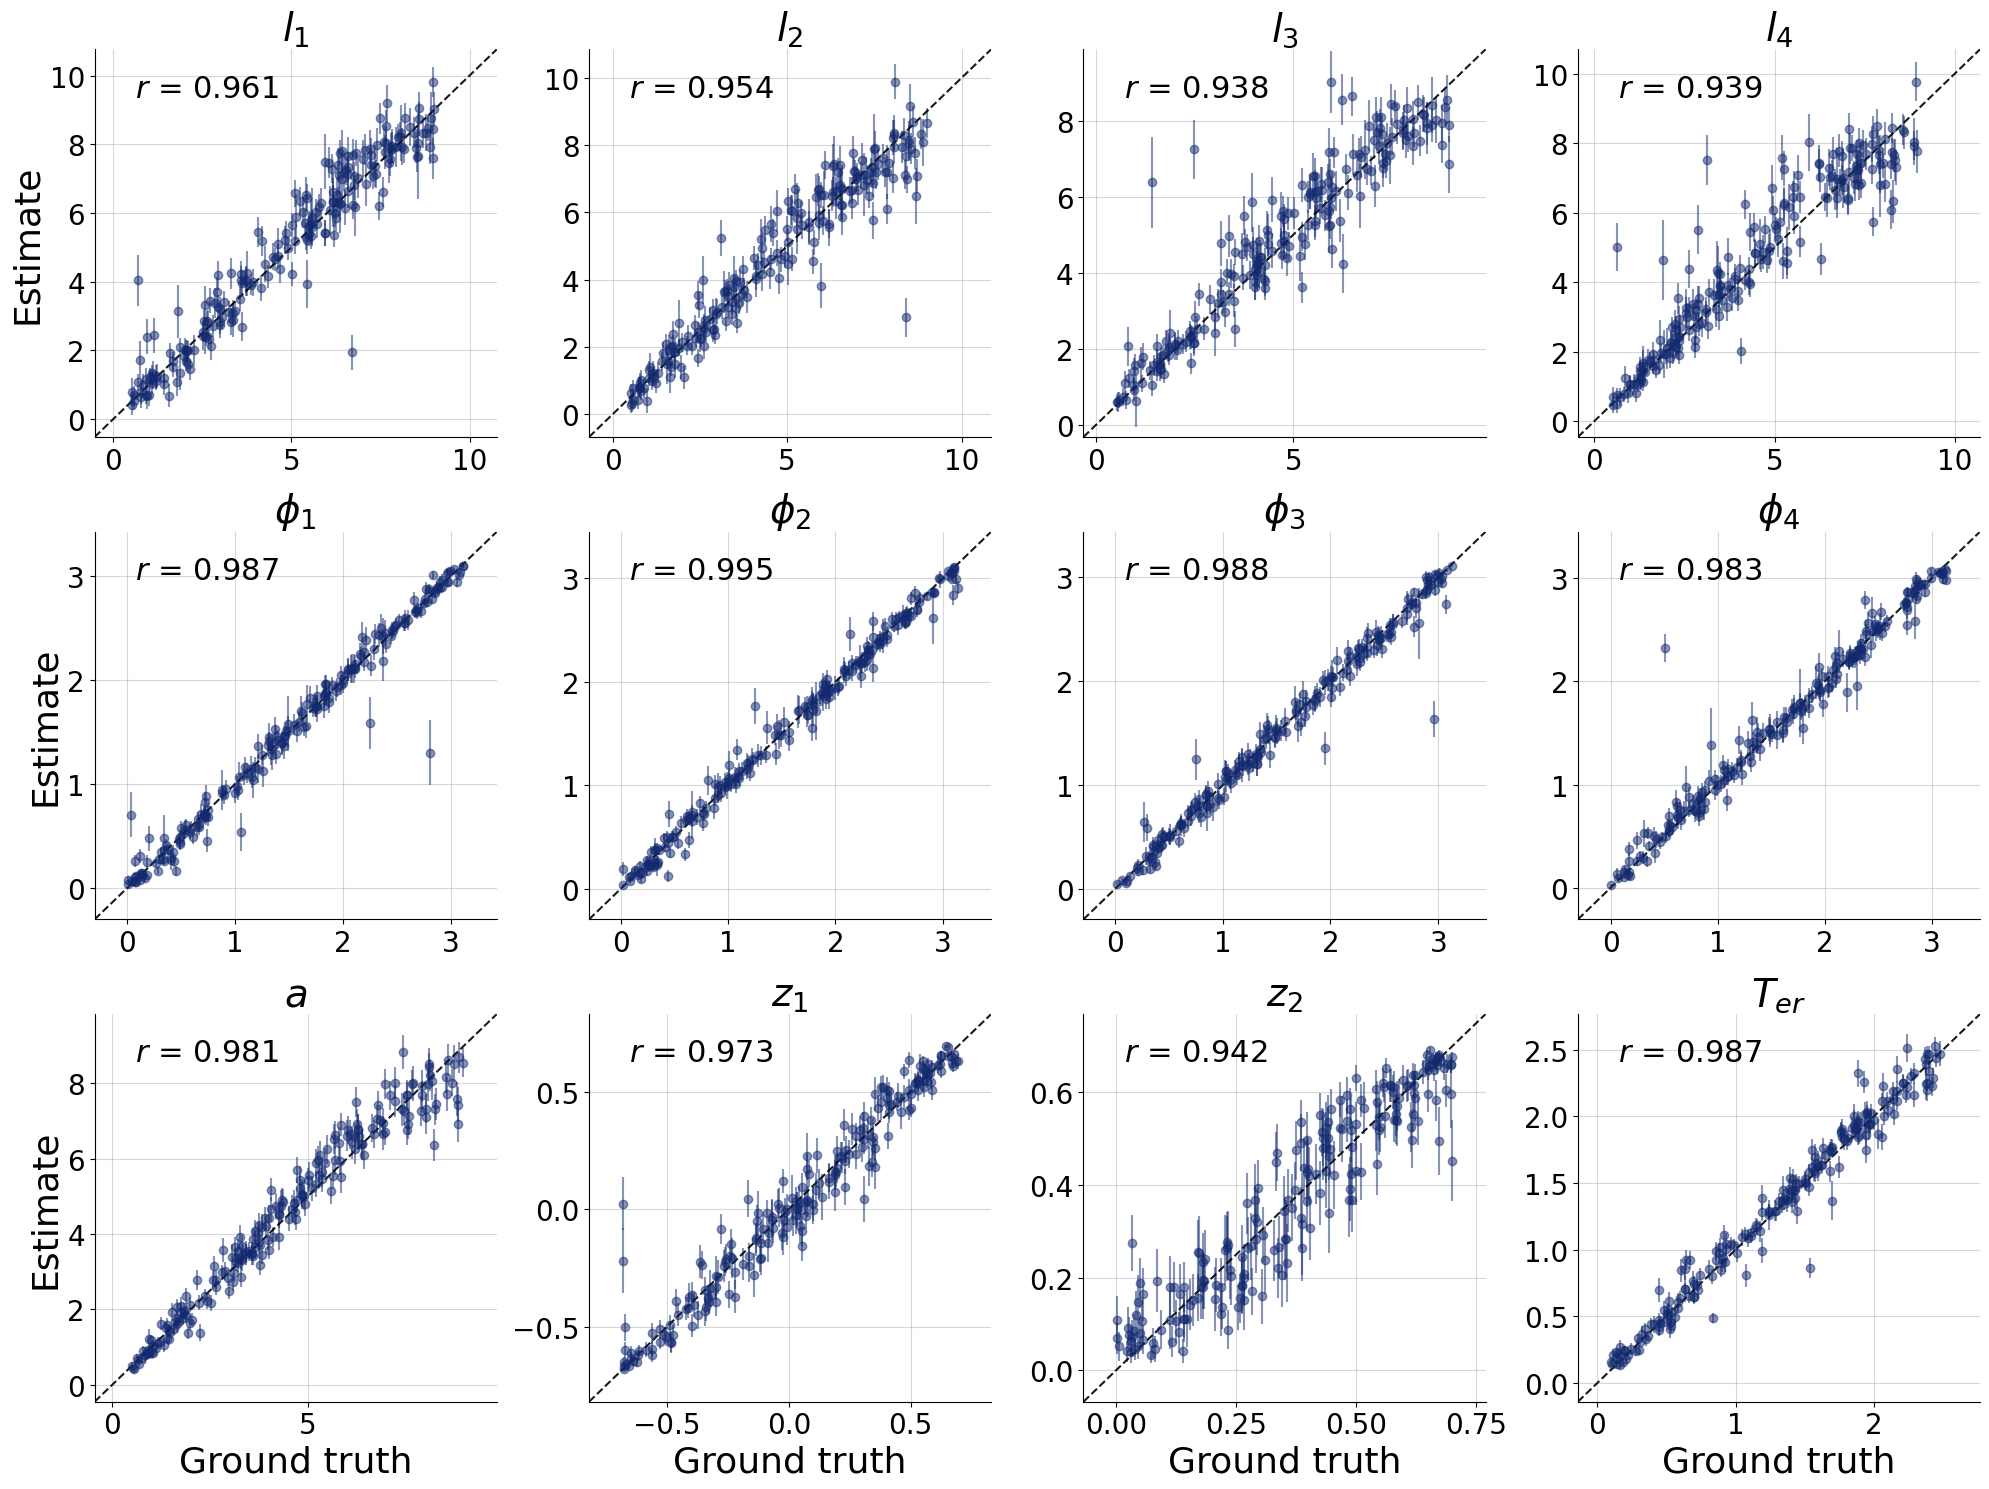

In [16]:
variable_names = [r'$l_1$', r'$l_2$', r'$l_3$', r'$l_4$', 
                  r'$\phi_1$', r'$\phi_2$', r'$\phi_3$', r'$\phi_4$',
                  r'$a$', r'$z_1$',r'$z_2$', r'$T_{er}$']

f = bf.diagnostics.plots.recovery(
    estimates=post_draws, 
    targets=val_sims,
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20
)

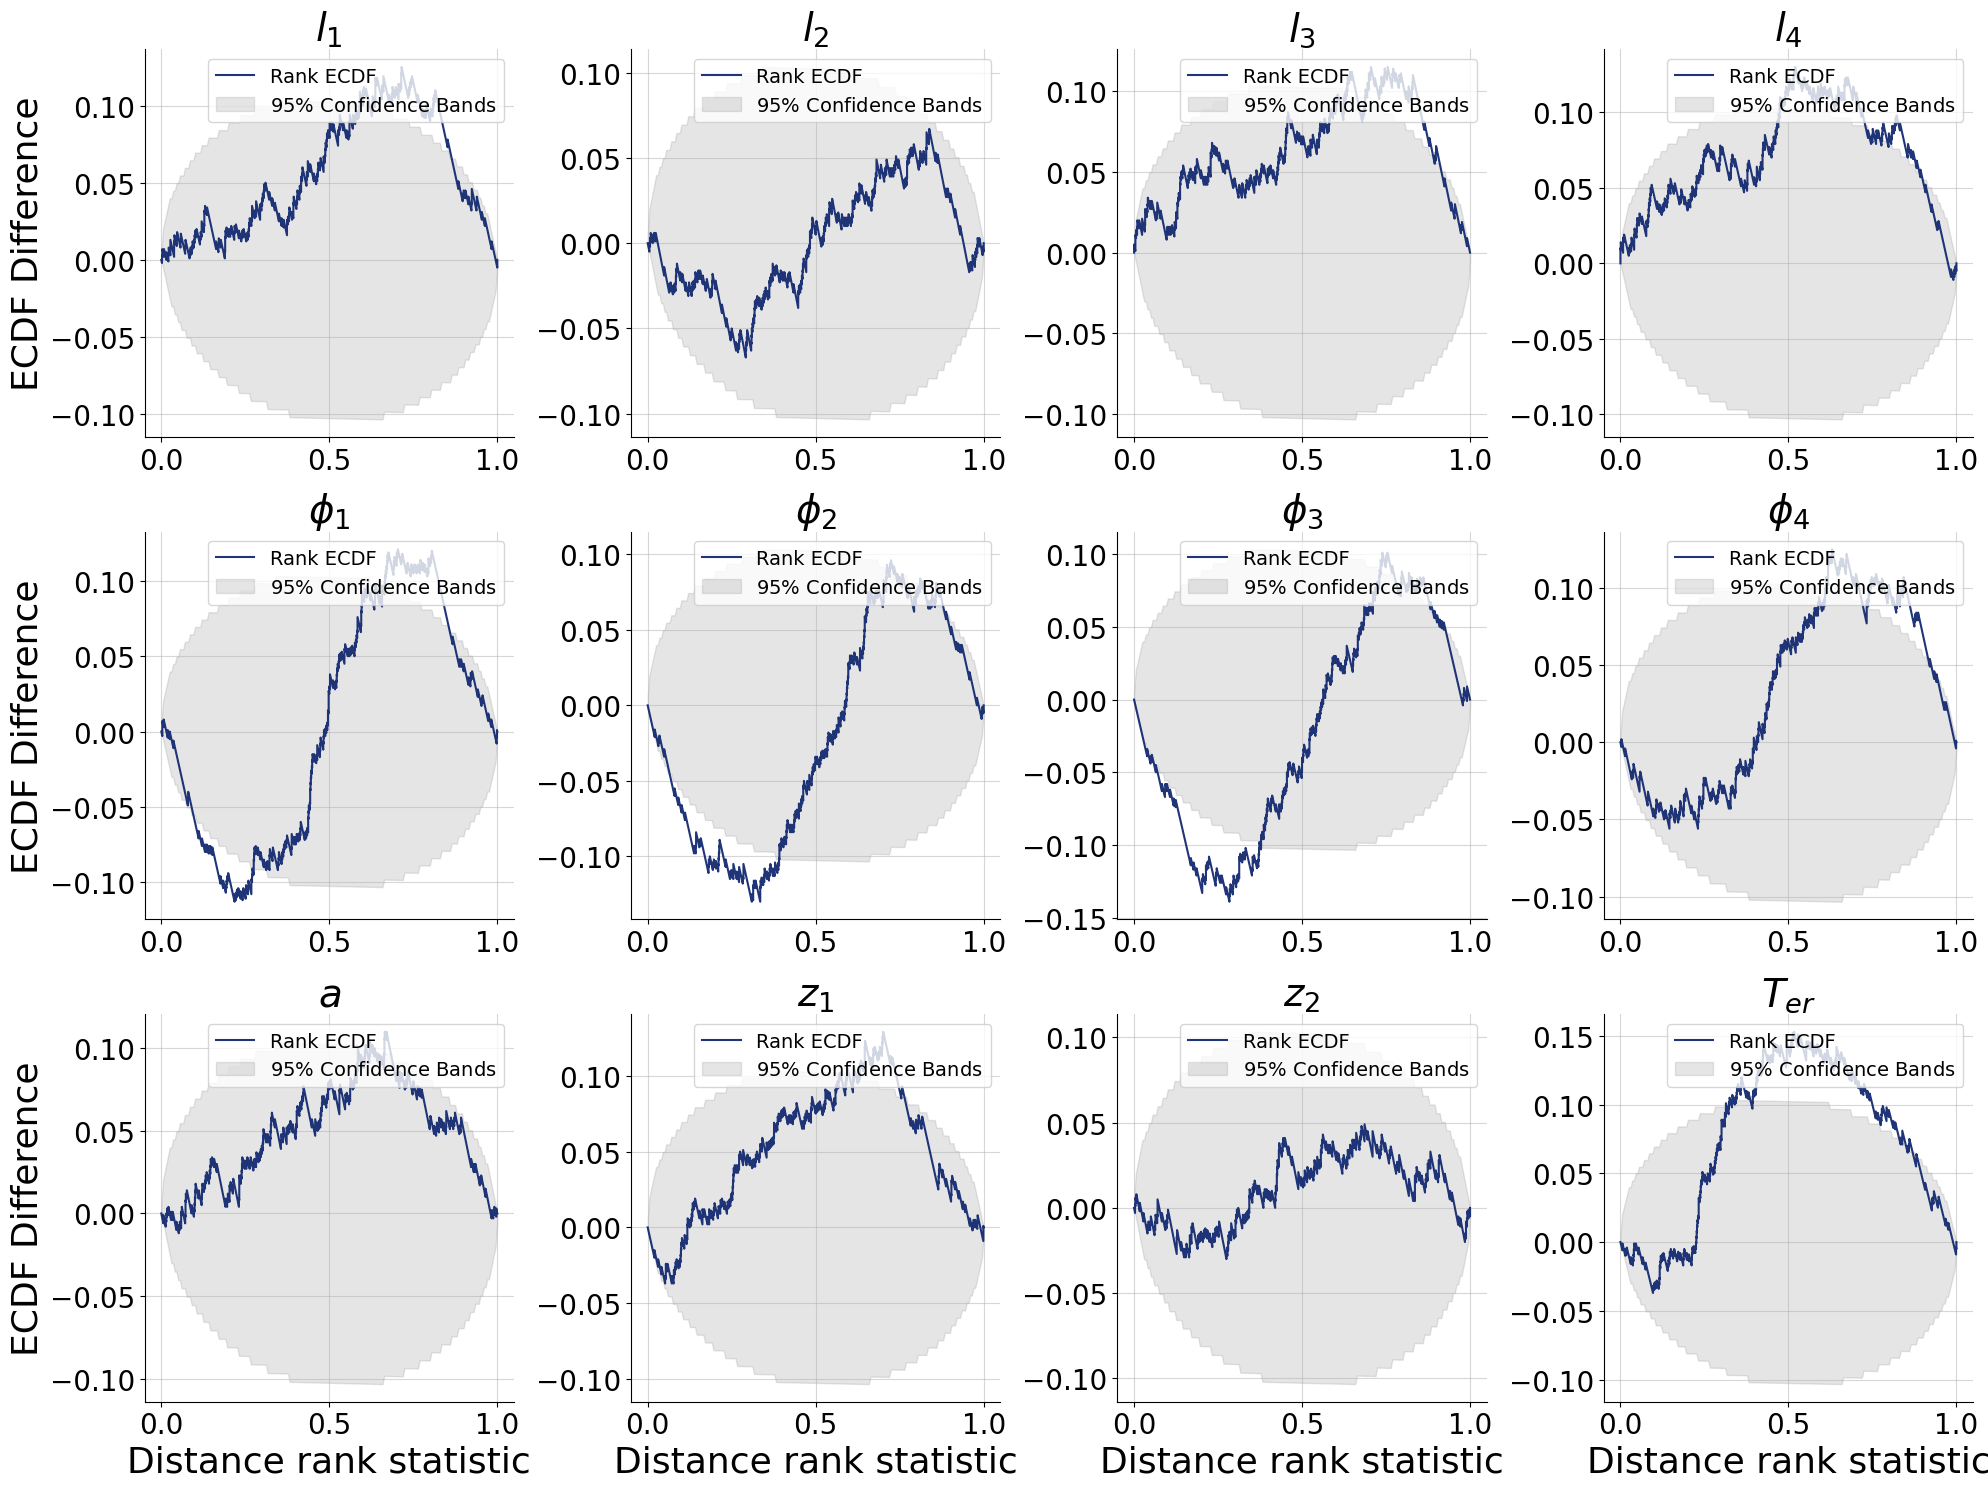

In [17]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates=post_draws, 
    targets=val_sims,
    difference = True,
    rank_type="distance",
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20
)
